In [ ]:
# Uncomment and modify this line as needed to install dependencies
#!pip install 'qiskit>=2.1.0' 'qiskit-ibm-runtime>=0.40.1' 'qiskit-aer>=0.17.0' 'numpy' 'pylatexenc'
import qiskit

  - This first toy example is now known as "Deutsch's algorithm."

## 1. Theory: The 1-Bit Black Box

Before we solve big problems, let's look at the absolute simplest problem a quantum computer can solve faster than a classical one.

**The Problem:**

        Imagine a "Black Box" (an Oracle) that takes exactly 1 bit of input (0 or 1) and gives exactly 1 bit of output (0 or 1).
Because there are only two possible inputs and two possible outputs, this box can only do one of four things:

|  |  |  |
| :---: | :---: | :--- |
  |Constant 0    |: No matter what you put in, it outputs 0. |
  |Constant 1  |: No matter what you put in, it outputs 1. |
 |Balanced (Identity)   |: Input 0 gives 0. Input 1 gives 1. |
  Balanced (NOT)        |: Input 0 gives 1. Input 1 gives 0. |

The Game: You need to figure out if the box is **Constant** or **Balanced**.

    - Classical Computer: You MUST test the box twice. You have to put in a '0', check the answer, then put in a '1', and check the answer. (2 Tries).

    - Quantum Computer: By putting the input into a superposition, the Deutsch Algorithm finds the answer in exactly 1 Try.

The Secret Weapon: Phase Kickback
We use an extra "helper" qubit (output qubit) set to the $\vert{}-\rangle$ state. When the Oracle does its calculation, it "kicks" a negative sign (phase) back onto the input qubit ONLY if the function is balanced. We then use a final Hadamard gate to read that phase!

2. Code: Building a Balanced Oracle

Let's write the code for a Balanced Oracle (specifically, the one where the output simply copies the input).





--- Deutsch Algorithm Circuit ---


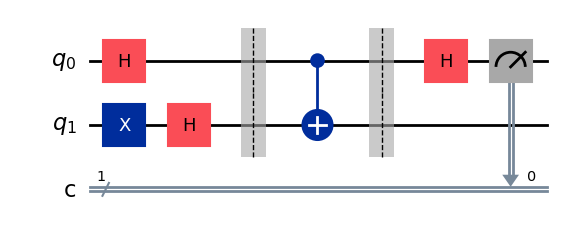


Measurement Result: {'1': 1}
Success: The Quantum Computer knows it is BALANCED in 1 shot!


In [15]:
## Apply Hadamards → Uf → Hadamards → measure.
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# --- Step 1: Setup the Circuit ---
# We need 1 Input Qubit (q0) and 1 Output/Helper Qubit (q1)
qc = QuantumCircuit(2, 1) # 2 qubits, 1 classical bit for measuring q0

# --- Step 2: Prepare the States ---
# Put the input qubit (q0) into superposition
qc.h(0)

# Put the helper qubit (q1) into the |-> state (X then H)
# This is required for the "Phase Kickback" magic to work!
qc.x(1)
qc.h(1)

qc.barrier()

# --- Step 3: THE ORACLE (Black Box) ---
# We will build a BALANCED oracle. 
# A simple CNOT gate works perfectly. If q0 is 1, it flips q1.
qc.cx(0, 1)

qc.barrier()

# --- Step 4: The Interference & Measurement ---
# Apply a final H-gate to the input qubit. 
# This converts the "kicked back" phase into a readable 0 or 1.
qc.h(0)

# Measure ONLY the input qubit (q0)
qc.measure(0, 0)

# --- Visualize ---
print("--- Deutsch Algorithm Circuit ---")
display(qc.draw('mpl'))

# --- Simulate ---
sim = AerSimulator()
result = sim.run(qc, shots=1).result() # 1 Shot is all we need!
counts = result.get_counts()

print("\nMeasurement Result:", counts)

# --- Logic Check ---
# Result '0' = Constant
# Result '1' = Balanced
if '1' in counts:
    print("Success: The Quantum Computer knows it is BALANCED in 1 shot!")
else:
    print("Success: The Quantum Computer knows it is CONSTANT in 1 shot!")


## 3. Exercises (Homework)

To truly prove this works, you must build the other types of Oracles!

### Exercise 1: Build a "Constant 0" Oracle

$Goal$: Prove the circuit outputs 0 when the Oracle does nothing.

$Task$: In Step 3 (The Oracle), delete the qc.cx(0, 1) gate entirely. Leave that section blank.

Action: Run the code.

$Result$: Because the Oracle did nothing (Constant 0), no phase was kicked back. The final H-gate returned the qubit safely to 0.

## Exercise 2: Build a "Constant 1" Oracle

$Goal$: Prove the circuit outputs 0 even if the Oracle constantly outputs 1.

$Task$: In Step 3, replace the CNOT gate with an X-gate on the helper qubit: qc.x(1).

Why? This flips the output to 1 regardless of what the input is.

Action: Run the code.

Result: You should still measure 0. The quantum computer successfully identified it as a Constant function!

### Instructor Note (For your tutorial)

"Make sure your students understand the role of Qubit 1 (the helper/ancilla). We never even measure it! Its only job is to be in the $\vert{}-\rangle$ state so that the Oracle can bounce a negative phase off of it and back onto Qubit 0. This 'Phase Kickback' is the engine that drives almost all quantum algorithms!"

# **The Deutsch-Jozsa Algorithm**

## 1. Theory: The $n$-bit Black Box

In the standard Deutsch Algorithm, our Oracle only took a single coin flip (1 qubit). But what if our Black Box takes a **multi-bit password** (like `101` or `0110`) as input?

**The Problem:**
We have a hidden function $f(x)$ that takes an $n$-bit input and outputs a single bit (0 or 1). We are promised that the machine is set to one of two modes:

1. **Constant:** It outputs the exact same thing (all 0s or all 1s) no matter what input you give it.
2. **Balanced:** It outputs 0 for exactly half of the possible inputs, and 1 for the other half.

**The Challenge:**
How many times do we need to check the machine to know if it is Constant or Balanced?

* **Classical Computer:** If the input is $n$ bits long, there are $2^n$ possible inputs. To be 100% sure, a classical computer might have to check over half of them in the worst-case scenario. For a 10-bit input, that's $513$ checks!
* **Quantum Computer:** Using the Deutsch-Jozsa algorithm, we can find out in exactly **ONE single try**, no matter how many bits there are.

**How it works:**
We use the exact same logic as the 1-qubit Deutsch algorithm! We put all input qubits into superposition, put our output qubit in the $\vert{}-\rangle$ state for Phase Kickback, run the Oracle once, and then apply H-gates again to cause interference.

---

## 2. Code: Implementing a 3-Qubit DJ Algorithm

Let's build a circuit with 3 input qubits ($n=3$) and 1 output qubit. We will build a **Balanced** Oracle.


Deutsch-Jozsa Circuit:


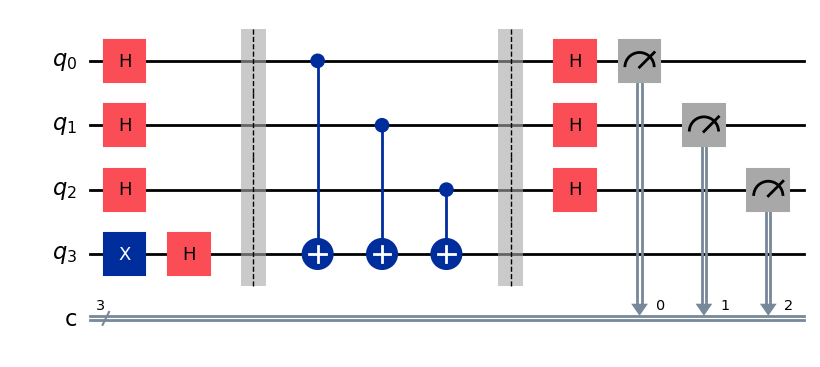


Measurement Result: {'111': 1}
Conclusion: The Oracle is BALANCED!


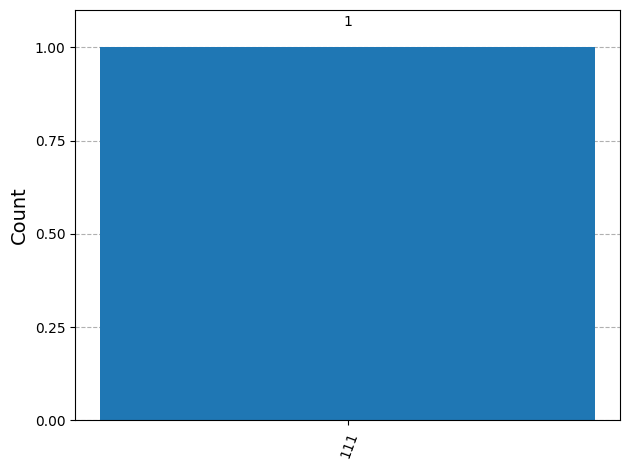

In [25]:

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

n = 3 # Number of input qubits

# --- Step 1: Initialize Circuit ---
# We need 'n' input qubits and 1 output qubit. 
# We also need 'n' classical bits to measure the inputs.
qc = QuantumCircuit(n + 1, n)

# --- Step 2: Setup the Qubits ---
# Put all input qubits into superposition
for i in range(n):
    qc.h(i)

# Put the output qubit (qubit n) into the |-> state for Phase Kickback
qc.x(n)
qc.h(n)

qc.barrier()

# --- Step 3: THE ORACLE (Balanced) ---
# A simple way to make a balanced oracle is to apply CNOTs 
# from every input qubit to the output qubit.
for i in range(n):
    qc.cx(i, n)

qc.barrier()

# --- Step 4: Interference and Measurement ---
# Apply H-gates to all input qubits again
for i in range(n):
    qc.h(i)

# Measure ONLY the input qubits
for i in range(n):
    qc.measure(i, i)

# --- Visualize ---
print("Deutsch-Jozsa Circuit:")
display(qc.draw('mpl'))

# --- Simulate ---
sim = AerSimulator()
# Notice shots=1. We only need to run this once!
result = sim.run(qc, shots=1).result() 
counts = result.get_counts()

print("\nMeasurement Result:", counts)

# --- Logic Check ---
# If the result is all zeros ('000'), it is CONSTANT.
# If the result is ANYTHING ELSE, it is BALANCED.
measured_string = list(counts.keys())[0]


if measured_string == '0' * n:
    print("Conclusion: The Oracle is CONSTANT!")
else:
    print("Conclusion: The Oracle is BALANCED!")

plot_histogram(counts)


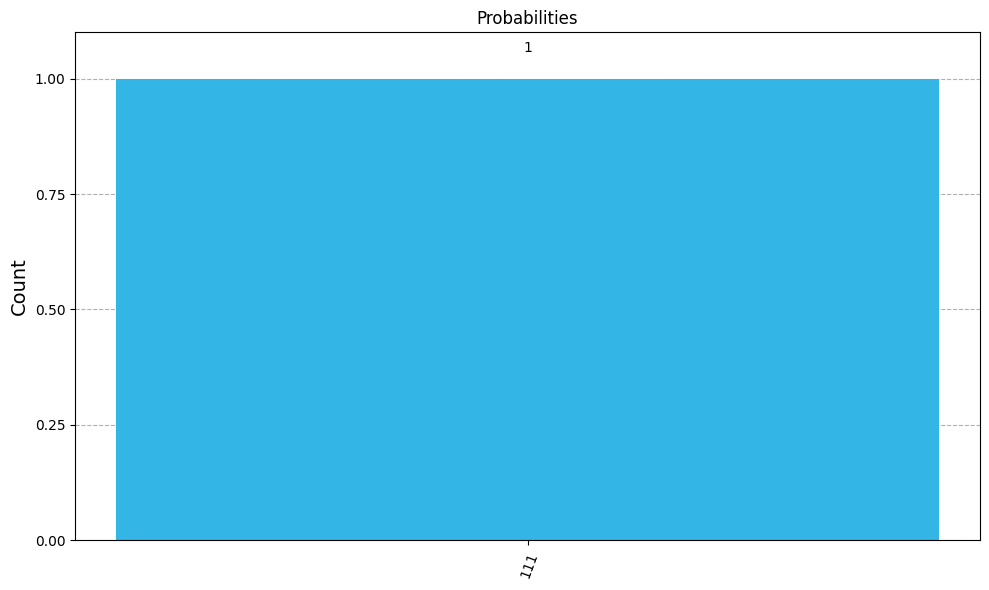

In [ ]:
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Assuming you already have your 'counts' from the simulation like this:
# result = sim.run(qc, shots=1024).result()
# counts = result.get_counts()

# --- Visualization Code ---
# We use a custom color to match the blue bar in your image
fig = plot_histogram(
    counts, 
    title="Probabilities", 
    figsize=(10, 6), 
    color="#8333e5" # The vibrant blue color from your image
)

# Display the plot in the notebook
display(fig)

## 3. Exercises (Hands-on Practice)

### Exercise 1: Build a Constant Oracle

**Goal:** Prove that the circuit works for a Constant function too.

* **Task:** Replace the Oracle section in the code above. Delete the `for` loop that adds the `cx` gates. Leave the space entirely blank (this represents an Oracle that always outputs 0).
* **Expected Result:** When you run the simulation, your measured result should be exactly `000`.

### Exercise 2: A Tricky Balanced Oracle

**Goal:** Make a different balanced oracle so students see there are multiple ways to build them.

* **Task:** Inside the Oracle section, before applying the CNOT gates, apply an `x` gate to just the first input qubit (`qc.x(0)`). Then apply your CNOTs. Then apply `qc.x(0)` again to revert it.
* **Observation:** This changes the internal logic of the Oracle, but it is still fundamentally "Balanced". Run the circuit—does the final answer still correctly identify it as Balanced? (Spoiler: Yes, it will not measure `000`!).

Simon's Circuit (Hidden String s = '11'):


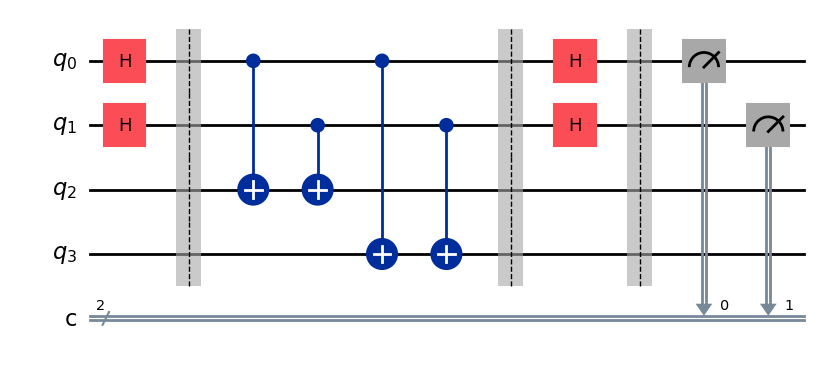

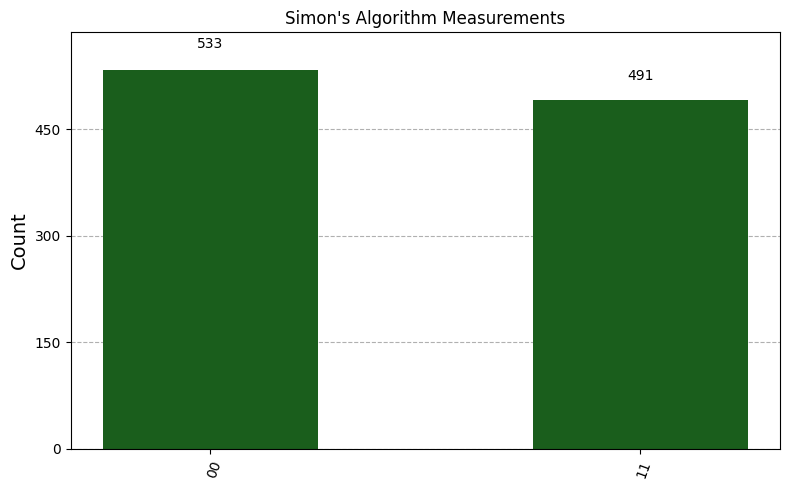

In [5]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

n = 2 # Length of our secret string
secret_s = '11'

# --- Step 1: Initialize Circuit ---
# We need 'n' input qubits, 'n' output qubits, and 'n' classical bits
qc = QuantumCircuit(n * 2, n)

# --- Step 2: Superposition ---
# Apply H-gates ONLY to the input register (qubits 0 and 1)
for i in range(n):
    qc.h(i)

qc.barrier()

# --- Step 3: THE ORACLE for s = '11' ---
# This oracle guarantees that f(x) = f(x XOR 11)
# Copy input to output
qc.cx(0, 2)
qc.cx(1, 2)
qc.cx(0, 3)
qc.cx(1, 3)

qc.barrier()

# --- Step 4: Interference ---
# Apply H-gates to the input register again
for i in range(n):
    qc.h(i)

qc.barrier()

# --- Step 5: Measurement ---
# Measure the input register (qubits 0 and 1)
for i in range(n):
    qc.measure(i, i)

# --- Visualize Circuit ---
print(f"Simon's Circuit (Hidden String s = '{secret_s}'):")
display(qc.draw('mpl'))

# --- Simulate ---
sim = AerSimulator()
result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

# --- Visualization ---
fig = plot_histogram(
    counts, 
    title="Simon's Algorithm Measurements", 
    figsize=(8, 5), 
    color="#1a5e1c" # The vibrant blue you like!
)
display(fig)

## 3. Post-Processing: Finding the Secret

When you run the code above, your histogram will show a roughly 50/50 split between two results: **`00`** and **`11`**.

Let's use classical math to solve for $s$ (which we know is $s_1 s_0$):

1. **Measurement 1:** You measured `00`.
Equation: $(0 \cdot s_1) \oplus (0 \cdot s_0) = 0$. (This tells us nothing useful).
2. **Measurement 2:** You measured `11`.
Equation: $(1 \cdot s_1) \oplus (1 \cdot s_0) = 0 \implies s_1 \oplus s_0 = 0$.
3. **Conclusion:** For $s_1 \oplus s_0 = 0$ to be true, $s_1$ must equal $s_0$. Since the string cannot be all zeros (by definition of the problem), the secret string must be **`11`**. We found it!

---

## 4. Exercises (Hands-on Practice)

### Exercise 1: One-to-One Oracle ($s = 00$)

**Goal:** Understand what happens when there is no hidden duplicate (a 1-to-1 function).

* **Task:** Rewrite the Oracle section. Erase the 4 CNOT gates and replace them with just two: `qc.cx(0, 2)` and `qc.cx(1, 3)`. This perfectly copies the input to the output.
* **Observation:** Run the circuit. Your histogram will now show equal probabilities for `00`, `01`, `10`, and `11`. This flat distribution is the quantum computer's way of telling you that the secret string $s$ is empty (`00`)!

### Exercise 2: The Math Verification

**Goal:** Prove the phase equation works.

* **Task:** If the secret string was $s = 10$, the only measurement results you would ever see are `00` and `01`.
* **Math:** Write out the equation for the measurement `01` using $z \cdot s = 0 \pmod{2}$. Does it correctly point to the secret string `10`?